In [4]:
"""
FIXED Dataset Patching Script for U-Net Training

Key fixes:
1. Proper patchify indexing: patches[i, j, 0, :, :, :] instead of patches[i, j, :, :, :]
2. Safe filename generation with zero-padding to avoid collisions
3. cv2.imwrite validation with error checking
4. Proper cleanup on failed saves
5. Atomic save operations (both image and mask must succeed)
"""

import cv2
import numpy as np
from pathlib import Path
from patchify import patchify
from tqdm import tqdm
import random
import matplotlib.pyplot as plt

In [5]:
class DatasetPatcher:
    """Handles image patching with proper padding for U-Net training."""
    
    def __init__(self, patch_size=256, overlap=0.5):
        """
        Args:
            patch_size: Size of square patches (default 256)
            overlap: Overlap fraction (default 0.5 for 50%)
        """
        self.patch_size = patch_size
        self.step = int(patch_size * (1 - overlap))
        
    def calculate_padded_size(self, size):
        """
        Calculate the padded size to ensure exact patch division.
        
        The patchify library requires: (size - patch_size) % step == 0
        
        Args:
            size: Original image dimension (height or width)
            
        Returns:
            Padded size that satisfies the patchify requirement
        """
        if size < self.patch_size:
            return self.patch_size
        
        # Calculate how many additional pixels needed
        remainder = (size - self.patch_size) % self.step
        if remainder == 0:
            return size
        
        # Pad to next valid size
        padding_needed = self.step - remainder
        return size + padding_needed
    
    def pad_image(self, image):
        """
        Pad image using reflection to avoid edge artifacts.
        
        Reflection padding mirrors the image at boundaries, which works
        well for biological images as it avoids creating artificial edges.
        
        Args:
            image: Input image (grayscale or RGB)
            
        Returns:
            Padded image with dimensions suitable for patching
        """
        h, w = image.shape[:2]
        target_h = self.calculate_padded_size(h)
        target_w = self.calculate_padded_size(w)
        
        # Calculate padding amounts (symmetric padding)
        pad_h = target_h - h
        pad_w = target_w - w
        
        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left
        
        # Use reflection padding to avoid discontinuities
        if len(image.shape) == 2:
            padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), 
                          mode='reflect')
        else:
            padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), 
                          mode='reflect')
        
        return padded
    
    def create_patches(self, image):
        """
        Create patches from image using patchify.
        
        IMPORTANT: patchify returns shape (n_h, n_w, 1, patch_h, patch_w, channels)
        The middle dimension (1) must be indexed explicitly when extracting patches.
        
        Args:
            image: Padded image
            
        Returns:
            Array of patches with shape (n_patches_h, n_patches_w, 1, patch_size, patch_size, channels)
        """
        if len(image.shape) == 2:
            # Grayscale image - add channel dimension for patchify
            image = np.expand_dims(image, axis=-1)
            patches = patchify(image, (self.patch_size, self.patch_size, 1), step=self.step)
            return patches
        else:
            # RGB or multi-channel image
            patches = patchify(image, (self.patch_size, self.patch_size, image.shape[2]), 
                             step=self.step)
            return patches


def find_mask_for_image(image_path, masks_dir, mask_type='root'):
    """
    Find the corresponding mask file for an image.
    
    Handles different naming conventions across datasets 23, 24, 25.
    
    Args:
        image_path: Path to image file
        masks_dir: Directory containing mask files
        mask_type: Type of mask to find ('root', 'seed', 'shoot')
        
    Returns:
        Path to mask file or None if not found
    """
    image_stem = image_path.stem
    masks_path = Path(masks_dir)
    
    # Try different naming patterns
    patterns = [
        f"{image_stem}_{mask_type}_mask.tif",
        f"{image_stem}_{mask_type}_mask.tiff",
        f"{image_stem}_{mask_type}.tif",
        f"{image_stem}_{mask_type}.tiff",
        f"{image_stem}_mask.tif",
        f"{image_stem}_mask.tiff",
        f"{image_stem}.tif",
        f"{image_stem}.tiff",
    ]
    
    for pattern in patterns:
        mask_file = masks_path / pattern
        if mask_file.exists():
            return mask_file
    
    return None


def safe_save_patch(patch, output_path, patch_type="image"):
    """
    Safely save a patch with validation and error checking.
    
    This function validates the patch data before saving and verifies
    the save was successful. Returns success status for atomic operations.
    
    Args:
        patch: Numpy array to save
        output_path: Path where to save the patch
        patch_type: "image" or "mask" for appropriate handling
        
    Returns:
        tuple: (success: bool, error_message: str or None)
    """
    try:
        # Validate input
        if patch is None:
            return False, "Patch is None"
        
        if patch.size == 0:
            return False, "Patch is empty (size=0)"
        
        # Check for invalid values
        if not np.isfinite(patch).all():
            return False, "Patch contains NaN or inf values"
        
        # Ensure uint8 dtype
        if patch.dtype != np.uint8:
            return False, f"Patch dtype is {patch.dtype}, expected uint8"
        
        # Handle dimensions
        if patch.ndim == 3 and patch.shape[2] == 1:
            # Remove singleton dimension
            patch = patch[:, :, 0]
        
        # Validate dimensions are reasonable
        if patch.shape[0] == 0 or patch.shape[1] == 0:
            return False, f"Invalid patch dimensions: {patch.shape}"
        
        # For masks, ensure 2D grayscale
        if patch_type == "mask":
            if patch.ndim == 3:
                return False, f"Mask should be 2D, got shape {patch.shape}"
        
        # For images, handle color space conversion
        if patch_type == "image" and patch.ndim == 3:
            # Convert RGB to BGR for OpenCV
            if patch.shape[2] == 3:
                patch = cv2.cvtColor(patch, cv2.COLOR_RGB2BGR)
        
        # Attempt to write
        success = cv2.imwrite(str(output_path), patch)
        
        if not success:
            return False, "cv2.imwrite returned False"
        
        # Verify file was created
        if not output_path.exists():
            return False, "File was not created"
        
        # Verify file size is reasonable
        file_size = output_path.stat().st_size
        if file_size == 0:
            output_path.unlink()  # Delete empty file
            return False, "File was created but is empty"
        
        # Basic sanity check on file size (should be at least a few hundred bytes for 256x256)
        if file_size < 100:
            output_path.unlink()
            return False, f"File size suspiciously small: {file_size} bytes"
        
        return True, None
        
    except Exception as e:
        return False, f"Exception during save: {str(e)}"


def process_paired_dataset(images_dir, masks_dir, output_images_dir, output_masks_dir, patcher, mask_type='root'):
    """
    Process image-mask pairs: pad and create patches.
    
    FIXED VERSION with proper patchify indexing and atomic saves.
    
    Args:
        images_dir: Path to input images
        masks_dir: Path to input masks
        output_images_dir: Path to save image patches
        output_masks_dir: Path to save mask patches
        patcher: DatasetPatcher instance
        mask_type: Type of mask to process ('root', 'seed', 'shoot')
    """
    images_path = Path(images_dir)
    output_images_path = Path(output_images_dir)
    output_masks_path = Path(output_masks_dir)
    
    output_images_path.mkdir(parents=True, exist_ok=True)
    output_masks_path.mkdir(parents=True, exist_ok=True)
    
    # Get all image files
    image_files = sorted(list(images_path.glob('*.png')) + 
                        list(images_path.glob('*.jpg')) + 
                        list(images_path.glob('*.jpeg')))
    
    print(f"Processing {len(image_files)} images from {images_dir}")
    
    patch_count = 0
    matched_count = 0
    unmatched_images = []
    failed_saves = []
    
    for img_file in tqdm(image_files, desc=f"Processing {images_path.name}"):
        # Find corresponding mask
        mask_file = find_mask_for_image(img_file, masks_dir, mask_type=mask_type)
        
        if mask_file is None:
            unmatched_images.append(img_file.name)
            continue
        
        matched_count += 1
        
        # Read image
        image = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
        
        if image is None:
            print(f"\nWarning: Could not read {img_file}, skipping...")
            continue
        
        # Ensure image is uint8
        if image.dtype != np.uint8:
            if image.dtype == np.uint16:
                image = (image / 256).astype(np.uint8)
            elif image.dtype == np.float32 or image.dtype == np.float64:
                image = (image * 255).astype(np.uint8)
            else:
                image = image.astype(np.uint8)
        
        # Handle different image types - convert all to RGB
        if len(image.shape) == 2:
            # Grayscale - convert to RGB for consistency
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif image.shape[2] == 4:
            # RGBA - convert to RGB
            image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGB)
        elif image.shape[2] == 3:
            # BGR - convert to RGB
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Read mask
        mask = cv2.imread(str(mask_file), cv2.IMREAD_UNCHANGED)
        
        if mask is None:
            print(f"\nWarning: Could not read mask {mask_file}, skipping...")
            continue
        
        # Ensure mask is uint8 grayscale
        if mask.dtype != np.uint8:
            if mask.dtype == np.uint16:
                mask = (mask / 256).astype(np.uint8)
            elif mask.dtype == np.float32 or mask.dtype == np.float64:
                mask = (mask * 255).astype(np.uint8)
            else:
                mask = mask.astype(np.uint8)
        
        if len(mask.shape) == 3:
            # Convert to grayscale if multi-channel
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        
        # Verify dimensions match
        if image.shape[:2] != mask.shape[:2]:
            print(f"\nWarning: Size mismatch for {img_file.name}: image {image.shape[:2]} vs mask {mask.shape[:2]}, skipping...")
            continue
        
        # Pad both image and mask identically
        padded_image = patcher.pad_image(image)
        padded_mask = patcher.pad_image(mask)
        
        # Create patches
        image_patches = patcher.create_patches(padded_image)
        mask_patches = patcher.create_patches(padded_mask)
        
        # Verify patch shapes match
        if image_patches.shape[:2] != mask_patches.shape[:2]:
            print(f"\nWarning: Patch count mismatch for {img_file.name}, skipping...")
            continue
        
        # Save patches with proper indexing
        # CRITICAL FIX: patchify returns (n_h, n_w, 1, patch_h, patch_w, channels)
        # Must use [i, j, 0, :, :, :] to extract the patch correctly
        for i in range(image_patches.shape[0]):
            for j in range(image_patches.shape[1]):
                # FIXED: Use index 0 for the third dimension
                img_patch = image_patches[i, j, 0, :, :, :]
                mask_patch = mask_patches[i, j, 0, :, :, :]
                
                # Remove singleton channel dimension if present
                if img_patch.shape[2] == 1:
                    img_patch = img_patch[:, :, 0]
                if mask_patch.shape[2] == 1:
                    mask_patch = mask_patch[:, :, 0]
                
                # Ensure patches are uint8 (should already be, but verify)
                if img_patch.dtype != np.uint8:
                    img_patch = img_patch.astype(np.uint8)
                if mask_patch.dtype != np.uint8:
                    mask_patch = mask_patch.astype(np.uint8)
                
                # FIXED: Use zero-padded filenames to avoid collisions
                # i=1, j=11 → "01_11" vs i=11, j=1 → "11_01" (unique)
                patch_filename = f"{img_file.stem}_patch_{str(i).zfill(3)}_{str(j).zfill(3)}.png"
                
                # Define paths
                img_patch_path = output_images_path / patch_filename
                mask_patch_path = output_masks_path / patch_filename
                
                # ATOMIC SAVE: Both must succeed or both fail
                # Save image patch first
                img_success, img_error = safe_save_patch(img_patch, img_patch_path, "image")
                
                if not img_success:
                    failed_saves.append({
                        'file': patch_filename,
                        'type': 'image',
                        'error': img_error
                    })
                    continue
                
                # Save mask patch
                mask_success, mask_error = safe_save_patch(mask_patch, mask_patch_path, "mask")
                
                if not mask_success:
                    # Mask save failed - delete the image patch to maintain consistency
                    if img_patch_path.exists():
                        img_patch_path.unlink()
                    failed_saves.append({
                        'file': patch_filename,
                        'type': 'mask',
                        'error': mask_error
                    })
                    continue
                
                # Both saved successfully
                patch_count += 1
    
    # Final statistics
    print(f"\nMatched {matched_count}/{len(image_files)} images with masks")
    print(f"Successfully created {patch_count} patch pairs")
    
    if failed_saves:
        print(f"\n  WARNING: {len(failed_saves)} patches failed to save:")
        for fail in failed_saves[:10]:
            print(f"  - {fail['file']} ({fail['type']}): {fail['error']}")
        if len(failed_saves) > 10:
            print(f"  ... and {len(failed_saves) - 10} more")
    
    if unmatched_images:
        print(f"\nWarning: {len(unmatched_images)} images without matching {mask_type} masks:")
        for name in unmatched_images[:10]:
            print(f"  - {name}")
        if len(unmatched_images) > 10:
            print(f"  ... and {len(unmatched_images) - 10} more")
    
    return patch_count, matched_count, len(image_files)


def verify_patches(images_dir, masks_dir, num_samples=5):
    """
    Verify patch alignment by displaying random samples.
    
    Args:
        images_dir: Directory containing image patches
        masks_dir: Directory containing mask patches
        num_samples: Number of random samples to display
    """
    images_path = Path(images_dir)
    masks_path = Path(masks_dir)
    
    # Get all patch files
    image_patches = sorted(list(images_path.glob('*.png')))
    
    if len(image_patches) == 0:
        print(f"No patches found in {images_dir}")
        return
    
    # Sample random patches
    samples = random.sample(image_patches, min(num_samples, len(image_patches)))
    
    for img_file in samples:
        # Corresponding mask file
        mask_file = masks_path / img_file.name
        
        if not mask_file.exists():
            print(f"  Warning: Mask not found for {img_file.name}")
            continue
        
        # Read image and mask
        image = cv2.imread(str(img_file))
        if image is None:
            print(f"  Warning: Could not read image {img_file.name}")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"  Warning: Could not read mask {mask_file.name}")
            continue
        
        # Normalize mask to binary
        mask_binary = (mask > 127).astype(np.uint8) * 255
        
        # Create overlay
        overlay = image.copy()
        # Highlight root pixels in green
        overlay[mask_binary == 255] = [0, 255, 0]
        # Blend
        blended = cv2.addWeighted(image, 0.6, overlay, 0.4, 0)
        
        # Display
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Image patch
        axes[0].imshow(image)
        axes[0].set_title(f'Image Patch\n{img_file.name}')
        axes[0].axis('on')
        axes[0].set_xlabel('Width (pixels)')
        axes[0].set_ylabel('Height (pixels)')
        
        # Binary mask
        axes[1].imshow(mask_binary, cmap='gray', vmin=0, vmax=255)
        axes[1].set_title('Binary Mask (Root Pixels)')
        axes[1].axis('on')
        axes[1].set_xlabel('Width (pixels)')
        axes[1].set_ylabel('Height (pixels)')
        
        # Overlay
        axes[2].imshow(blended)
        axes[2].set_title('Overlay (Roots in Green)')
        axes[2].axis('on')
        axes[2].set_xlabel('Width (pixels)')
        axes[2].set_ylabel('Height (pixels)')
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print(f"\nPatch: {img_file.name}")
        print(f"  Image shape: {image.shape}")
        print(f"  Mask shape: {mask_binary.shape}")
        print(f"  Root pixels: {np.sum(mask_binary == 255)} ({np.sum(mask_binary == 255) / mask_binary.size * 100:.2f}%)")
        print(f"  Unique pixel values in mask: {np.unique(mask)}")


def main():
    """
    Main execution function to prepare the entire dataset.
    """
    # Configuration
    SYMLINK_DATA = Path("../data/processed/dataset_24")
    OUTPUT_BASE = Path("../data/processed/dataset_24_patches_fixed")
    
    # Initialize patcher with 256x256 patches and 50% overlap
    patcher = DatasetPatcher(patch_size=256, overlap=0.5)
    
    print("="*60)
    print("FIXED Dataset Preparation for U-Net Training - ROOT DETECTION")
    print("="*60)
    print(f"Patch size: {patcher.patch_size}x{patcher.patch_size}")
    print(f"Step size: {patcher.step} (50% overlap)")
    print("Processing ONLY root masks (ignoring seed/shoot masks)")
    print("="*60)
    print("\nKey fixes applied:")
    print("  ✓ Proper patchify indexing [i, j, 0, :, :, :]")
    print("  ✓ Zero-padded filenames to prevent collisions")
    print("  ✓ Atomic saves with validation")
    print("  ✓ Failed save tracking and cleanup")
    print("="*60)
    
    # Process training set
    print("\n[1/2] Processing training set (images + root masks)...")
    train_patches, train_matched, train_total = process_paired_dataset(
        SYMLINK_DATA / "train_images",
        SYMLINK_DATA / "train_masks",
        OUTPUT_BASE / "train_images",
        OUTPUT_BASE / "train_masks",
        patcher,
        mask_type='root'
    )
    
    # Process validation set
    print("\n[2/2] Processing validation set (images + root masks)...")
    val_patches, val_matched, val_total = process_paired_dataset(
        SYMLINK_DATA / "val_images",
        SYMLINK_DATA / "val_masks",
        OUTPUT_BASE / "val_images",
        OUTPUT_BASE / "val_masks",
        patcher,
        mask_type='root'
    )
    
    print("\n" + "="*60)
    print("Dataset preparation complete!")
    print(f"Patches saved to: {OUTPUT_BASE}")
    print("="*60)
    print(f"\nTraining set:")
    print(f"  - Matched: {train_matched}/{train_total} images")
    print(f"  - Created: {train_patches} patch pairs")
    print(f"\nValidation set:")
    print(f"  - Matched: {val_matched}/{val_total} images")
    print(f"  - Created: {val_patches} patch pairs")
    print("="*60)
    
    # Verification
    print("\n" + "="*60)
    print("Verification: Displaying random training samples")
    print("="*60)
    verify_patches(
        OUTPUT_BASE / "train_images",
        OUTPUT_BASE / "train_masks",
        num_samples=5
    )
    
    print("\n✓ Verification complete!")
    print(f"\nTo verify more samples, run:")
    print(f"verify_patches('{OUTPUT_BASE / 'train_images'}', '{OUTPUT_BASE / 'train_masks'}', num_samples=20)")


FIXED Dataset Preparation for U-Net Training - ROOT DETECTION
Patch size: 256x256
Step size: 128 (50% overlap)
Processing ONLY root masks (ignoring seed/shoot masks)

Key fixes applied:
  ✓ Proper patchify indexing [i, j, 0, :, :, :]
  ✓ Zero-padded filenames to prevent collisions
  ✓ Atomic saves with validation
  ✓ Failed save tracking and cleanup

[1/2] Processing training set (images + root masks)...
Processing 377 images from ..\data\processed\dataset_24\train_images


Processing train_images: 100%|██████████| 377/377 [27:26<00:00,  4.37s/it]  



Matched 377/377 images with masks
Successfully created 277472 patch pairs

[2/2] Processing validation set (images + root masks)...
Processing 50 images from ..\data\processed\dataset_24\val_images


Processing val_images: 100%|██████████| 50/50 [03:39<00:00,  4.38s/it]



Matched 50/50 images with masks
Successfully created 36800 patch pairs

Dataset preparation complete!
Patches saved to: ..\data\processed\dataset_24_patches_fixed

Training set:
  - Matched: 377/377 images
  - Created: 277472 patch pairs

Validation set:
  - Matched: 50/50 images
  - Created: 36800 patch pairs

Verification: Displaying random training samples


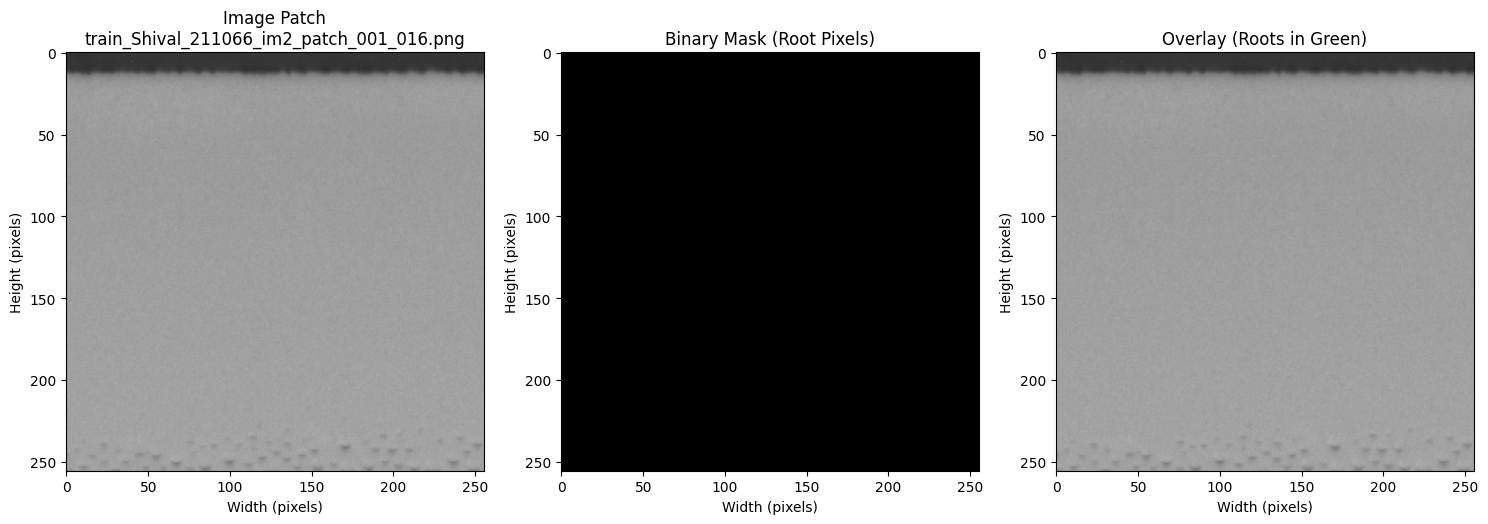


Patch: train_Shival_211066_im2_patch_001_016.png
  Image shape: (256, 256, 3)
  Mask shape: (256, 256)
  Root pixels: 0 (0.00%)
  Unique pixel values in mask: [0]


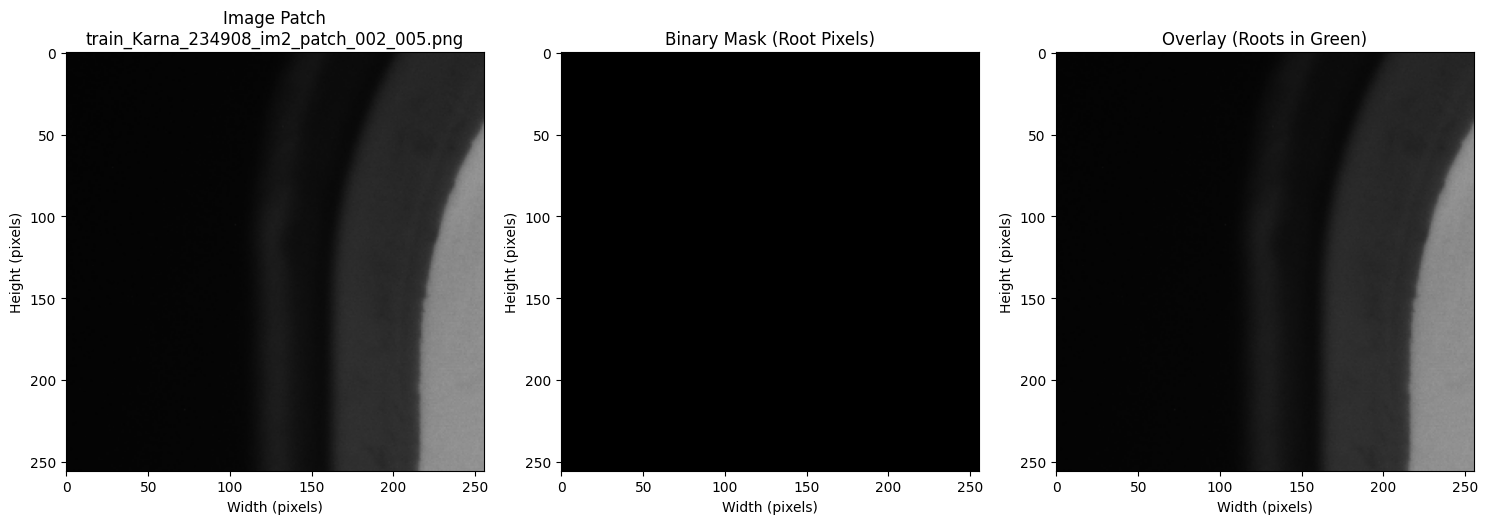


Patch: train_Karna_234908_im2_patch_002_005.png
  Image shape: (256, 256, 3)
  Mask shape: (256, 256)
  Root pixels: 0 (0.00%)
  Unique pixel values in mask: [0]


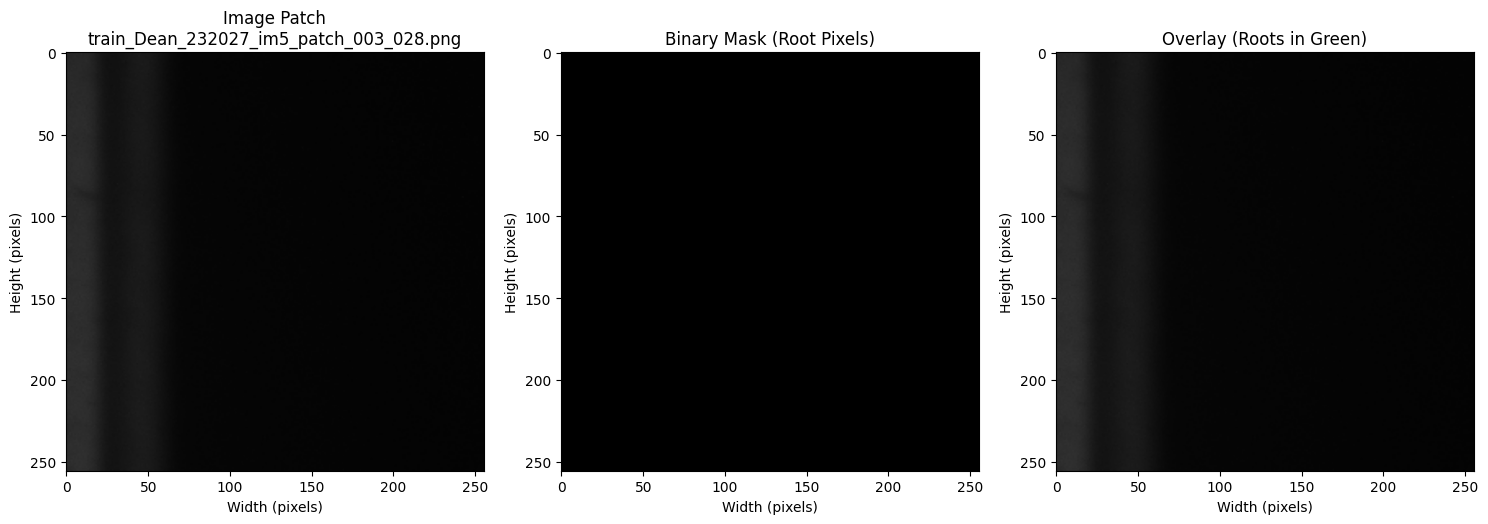


Patch: train_Dean_232027_im5_patch_003_028.png
  Image shape: (256, 256, 3)
  Mask shape: (256, 256)
  Root pixels: 0 (0.00%)
  Unique pixel values in mask: [0]


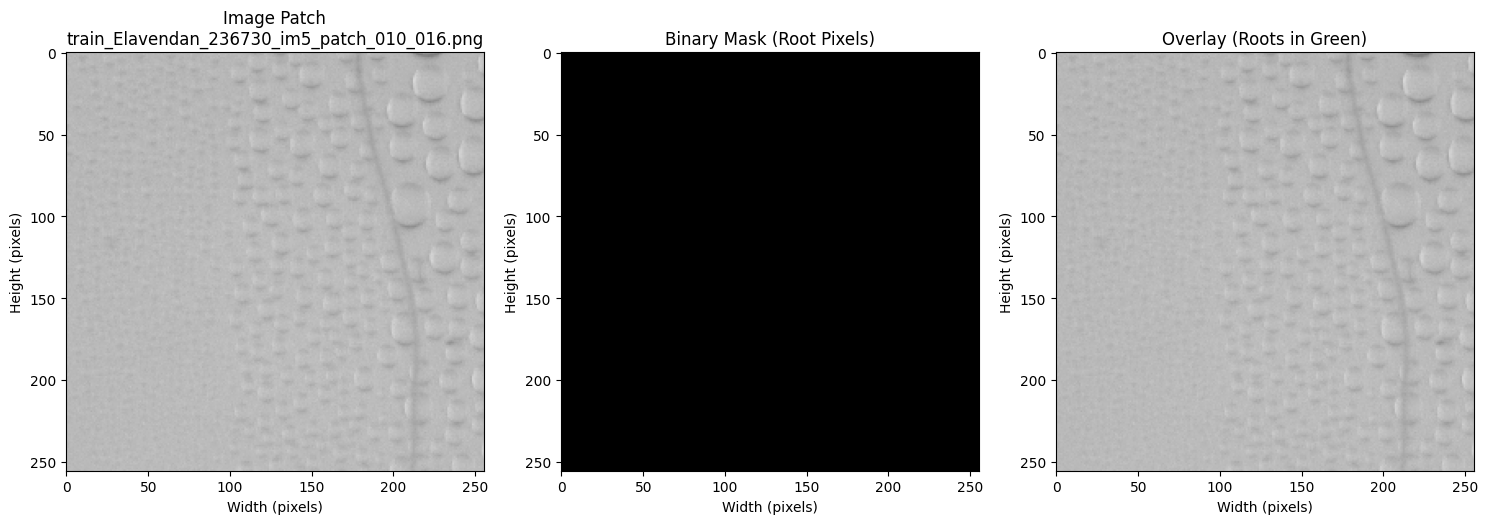


Patch: train_Elavendan_236730_im5_patch_010_016.png
  Image shape: (256, 256, 3)
  Mask shape: (256, 256)
  Root pixels: 0 (0.00%)
  Unique pixel values in mask: [0 1]


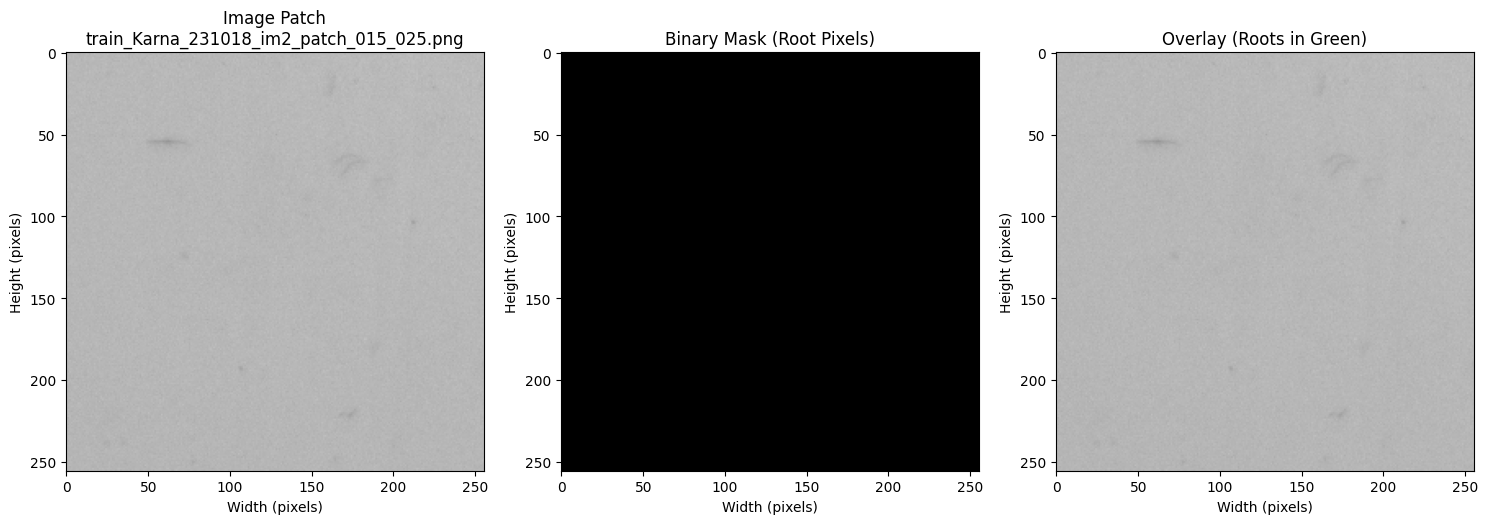


Patch: train_Karna_231018_im2_patch_015_025.png
  Image shape: (256, 256, 3)
  Mask shape: (256, 256)
  Root pixels: 0 (0.00%)
  Unique pixel values in mask: [0]

✓ Verification complete!

To verify more samples, run:
verify_patches('..\data\processed\dataset_24_patches_fixed\train_images', '..\data\processed\dataset_24_patches_fixed\train_masks', num_samples=20)


In [11]:
if __name__ == "__main__":
    main()

COMPLETE PATCH VERIFICATION PIPELINE

[Step 0] Listing available patch stems...

Found 377 unique image stems in ..\data\processed\dataset_24_patches_fixed\train_images
Displaying first 10:
--------------------------------------------------------------------------------
  1. 001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected
     (736 patches)
  2. 001_43-6-ROOT1-2023-08-08_pvdCherry_OD001_Col0_04-Fish Eye Corrected
     (736 patches)
  3. 002_43-19-ROOT1-2023-08-08_pvd_OD001_Col0_01-Fish Eye Corrected
     (736 patches)
  4. 002_43-6-ROOT1-2023-08-08_pvd_OD001_Col0_01-Fish Eye Corrected
     (736 patches)
  5. 003_43-18-ROOT1-2023-08-08_pvdCherry_OD01_f6h1_01-Fish Eye Corrected
     (736 patches)
  6. 003_43-6-ROOT1-2023-08-08_pvd_OD0001_f6h1_03-Fish Eye Corrected
     (736 patches)
  7. 004_43-11-ROOT1-2023-08-08_pvdCherry_OD0001_f6h1_03-Fish Eye Corrected
     (736 patches)
  8. 004_43-17-ROOT1-2023-08-08_pvd_OD001_f6h1_04-Fish Eye Corrected
     (736 patches)
  9. 005_

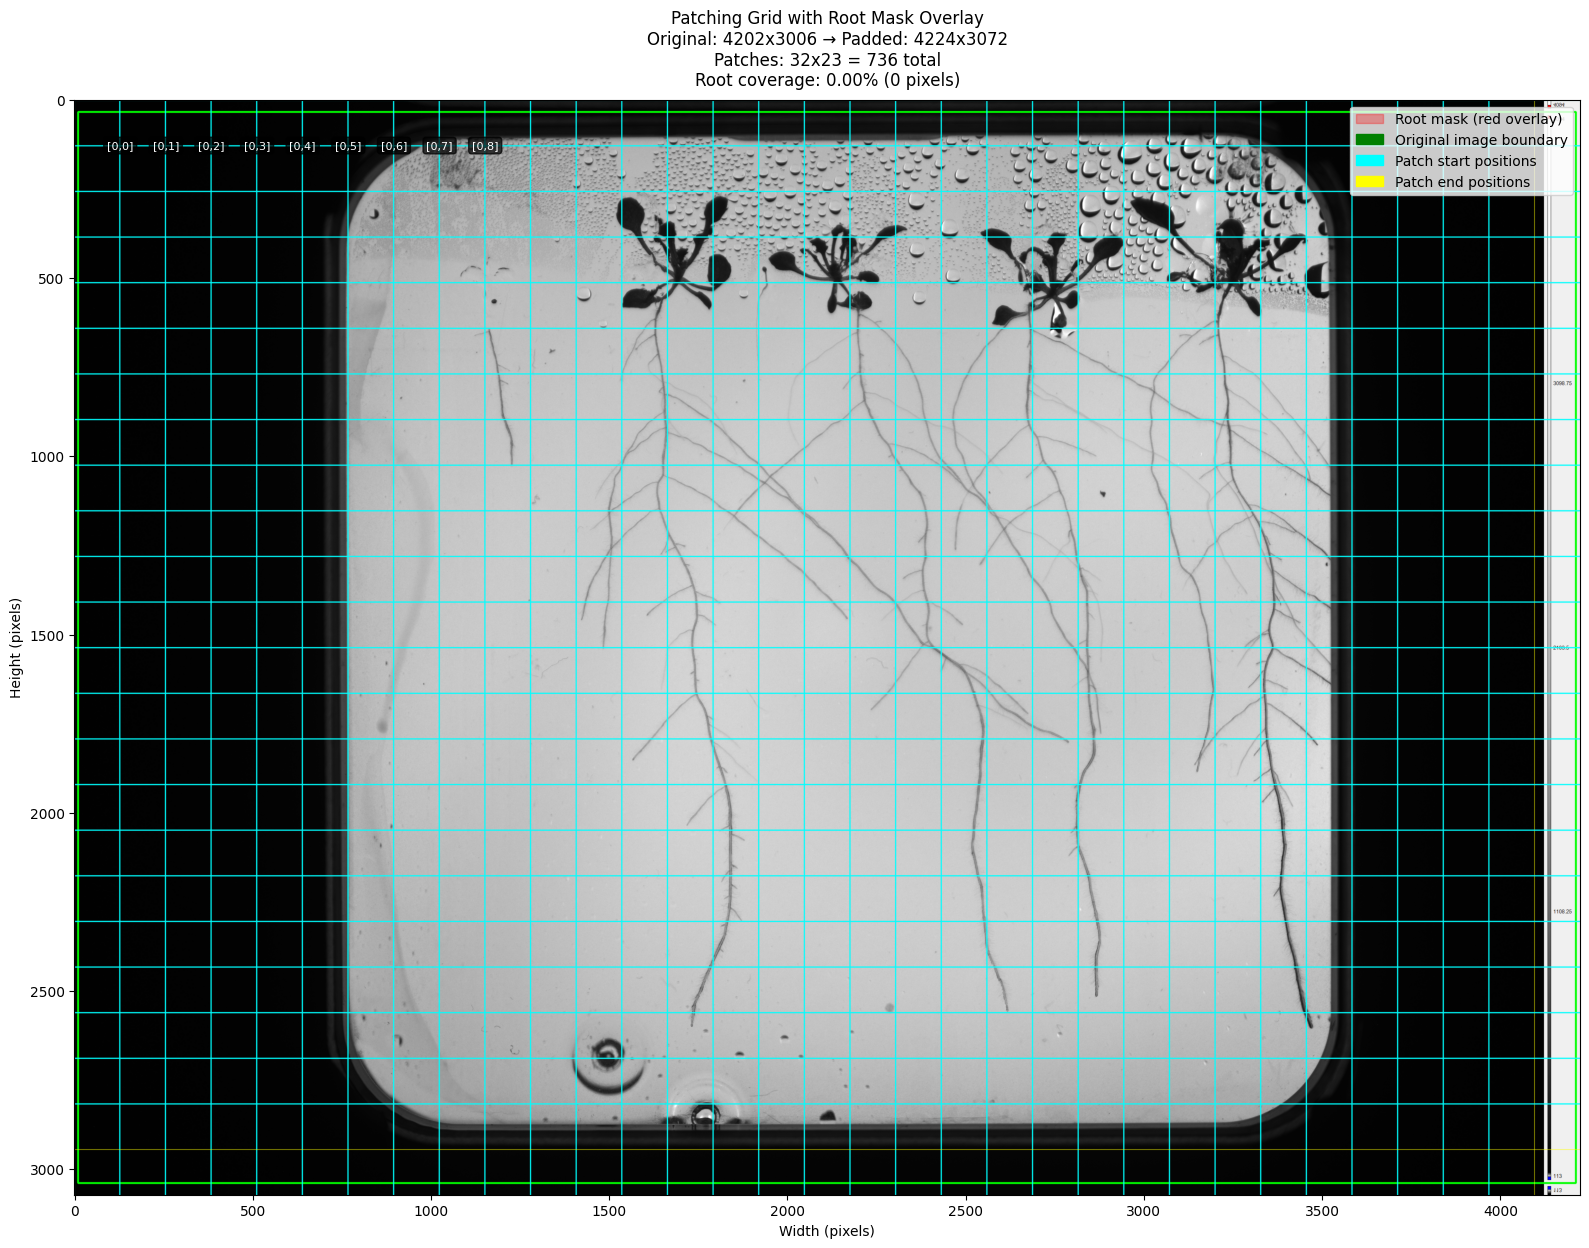


Patching Grid with Mask Details:
  Original dimensions: 4202 x 3006
  Padded dimensions:   4224 x 3072
  Total patches:       736
  Root coverage:       0.00%

[2/4] Reconstructing image from saved patches...

Searching for patches with stem: '001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected'
Search pattern: 001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected_patch_*.png
Found 736 patches

Found 736 patches for '001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected'
Grid size: 23 x 32
Expected patches: 736
Found patches: 736
Reconstructed size: 4224 x 3072
Successfully placed 736/736 patches
Reconstructed image saved to: ..\data\processed\visualizations\reconstructed_img_001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish .png

[3/4] Verifying image reconstruction accuracy...
Reconstructing from patches with stem: 001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected

Searching for patches with stem: '001_43-18-ROOT1-2023-08-08_pvd_OD001_Co

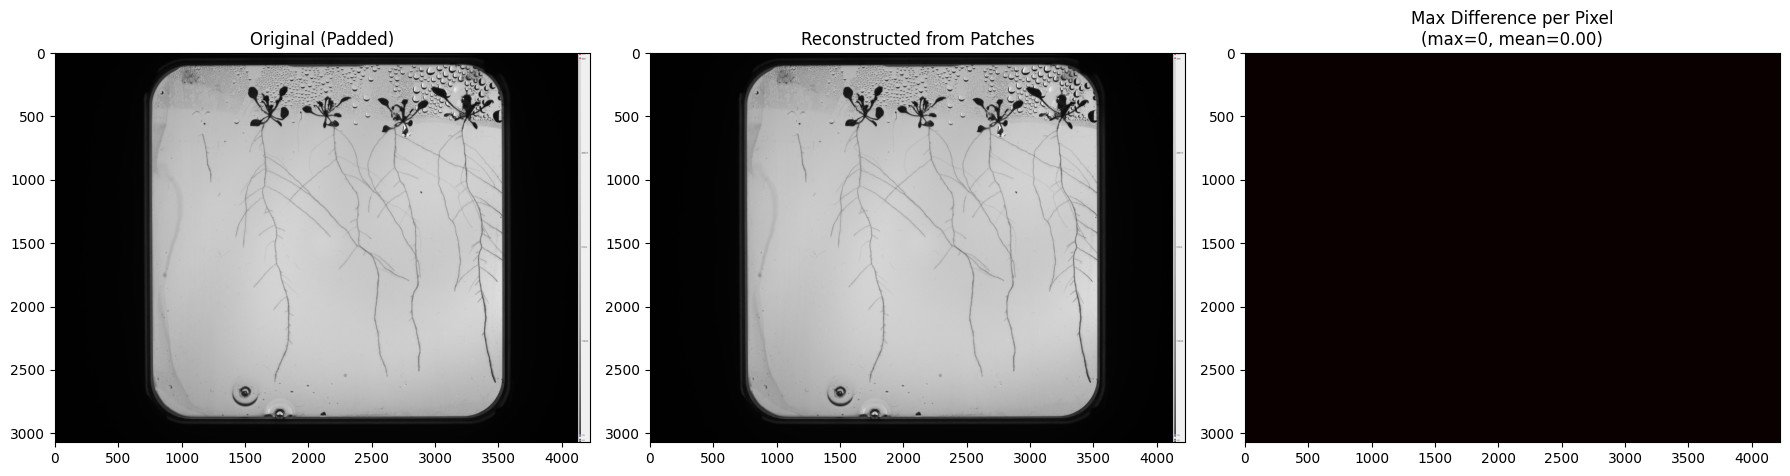


[4/4] Verifying mask reconstruction accuracy...
Note: Using image stem '001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected' for mask patches (paired data)
Reconstructing from patches with stem: 001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected

Searching for patches with stem: '001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected'
Search pattern: 001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected_patch_*.png
Found 736 patches

Found 736 patches for '001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish Eye Corrected'
Grid size: 23 x 32
Expected patches: 736
Found patches: 736
Reconstructed size: 4224 x 3072
Successfully placed 736/736 patches

Dimension Comparison:
  Original (padded): (3072, 4224)
  Reconstructed:     (3072, 4224)

Difference Metrics:
  Max difference:    0
  Mean difference:   0.0000
  Exact match:       100.00%


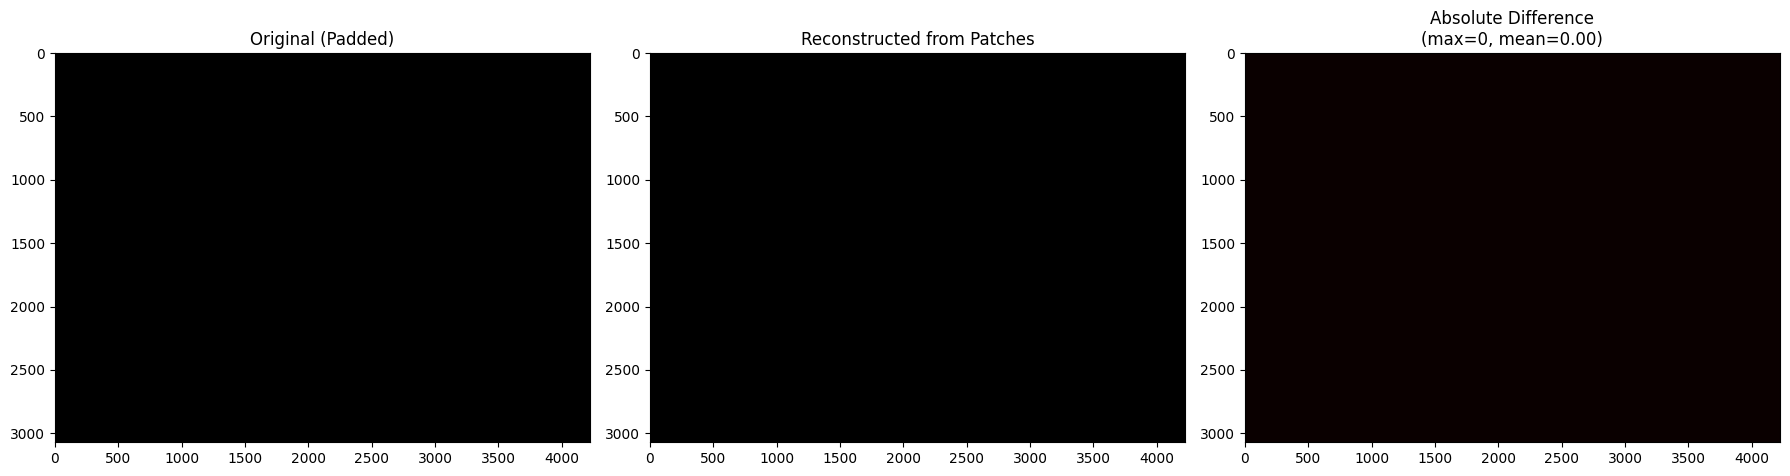


Verification Summary for 001_43-18-ROOT1-2023-08-08_pvd_OD001_Col0_02-Fish ...
  Image accuracy: 100.00%
  Mask accuracy:  100.00%

  SUCCESS: Perfect reconstruction!

All visualizations saved to: ..\data\processed\visualizations


In [11]:
def verify_reconstruction(original_image_path, patches_dir, patcher, is_mask=False, image_stem_override=None):
    """
    Compare original image with reconstructed version from patches.
    
    Approach:
    For masks, we need to use the image stem (not mask stem) since patches
    are saved with the image filename as base. The image_stem_override parameter
    allows us to specify the correct stem when the file being verified has a
    different naming convention.
    
    Args:
        original_image_path: Path to original image/mask
        patches_dir: Directory containing saved patches
        patcher: DatasetPatcher instance
        is_mask: True if comparing masks
        image_stem_override: Use this stem instead of deriving from filename
                            (needed when mask files have different names than images)
    
    Returns:
        Dictionary with comparison metrics
    """
    original_path = Path(original_image_path)
    
    # Read original
    original = cv2.imread(str(original_path), cv2.IMREAD_UNCHANGED)
    if original is None:
        raise ValueError(f"Could not read original: {original_path}")
    
    # Prepare original (same preprocessing as in main code)
    if len(original.shape) == 2:
        original_rgb = cv2.cvtColor(original, cv2.COLOR_GRAY2RGB)
    elif original.shape[2] == 4:
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGRA2RGB)
    elif original.shape[2] == 3:
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    else:
        original_rgb = original
    
    # Apply padding (same as during processing)
    padded_original = patcher.pad_image(original_rgb if not is_mask else original)
    
    # Determine which stem to use for reconstruction
    # For masks, use the override (image stem) if provided
    stem_to_use = image_stem_override if image_stem_override is not None else original_path.stem
    
    print(f"Reconstructing from patches with stem: {stem_to_use}")
    
    # Reconstruct from patches
    reconstructed = reconstruct_from_patches(
        patches_dir,
        stem_to_use,
        patcher
    )
    
    # Compare dimensions
    print("\nDimension Comparison:")
    print(f"  Original (padded): {padded_original.shape}")
    print(f"  Reconstructed:     {reconstructed.shape}")
    
    if padded_original.shape != reconstructed.shape:
        print("  ERROR: Dimension mismatch!")
        return None
    
    # Calculate difference metrics
    if is_mask or len(padded_original.shape) == 2:
        # For grayscale/masks
        if len(padded_original.shape) == 3:
            padded_original = cv2.cvtColor(padded_original, cv2.COLOR_RGB2GRAY)
        if len(reconstructed.shape) == 3:
            reconstructed = cv2.cvtColor(reconstructed, cv2.COLOR_RGB2GRAY)
        
        diff = np.abs(padded_original.astype(np.int16) - reconstructed.astype(np.int16))
        max_diff = np.max(diff)
        mean_diff = np.mean(diff)
        
        # Calculate pixel-wise accuracy
        exact_match = np.sum(diff == 0)
        total_pixels = diff.size
        accuracy = exact_match / total_pixels * 100
        
    else:
        # For RGB images
        diff = np.abs(padded_original.astype(np.int16) - reconstructed.astype(np.int16))
        max_diff = np.max(diff)
        mean_diff = np.mean(diff)
        
        exact_match = np.sum(np.all(diff == 0, axis=2))
        total_pixels = diff.shape[0] * diff.shape[1]
        accuracy = exact_match / total_pixels * 100
    
    print("\nDifference Metrics:")
    print(f"  Max difference:    {max_diff}")
    print(f"  Mean difference:   {mean_diff:.4f}")
    print(f"  Exact match:       {accuracy:.2f}%")
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    if is_mask or len(padded_original.shape) == 2:
        axes[0].imshow(padded_original, cmap='gray', vmin=0, vmax=255)
        axes[0].set_title('Original (Padded)')
        
        axes[1].imshow(reconstructed, cmap='gray', vmin=0, vmax=255)
        axes[1].set_title('Reconstructed from Patches')
        
        axes[2].imshow(diff, cmap='hot', vmin=0, vmax=max(1, max_diff))
        axes[2].set_title(f'Absolute Difference\n(max={max_diff}, mean={mean_diff:.2f})')
    else:
        axes[0].imshow(padded_original)
        axes[0].set_title('Original (Padded)')
        
        axes[1].imshow(reconstructed)
        axes[1].set_title('Reconstructed from Patches')
        
        # For RGB, show max difference across channels
        diff_max = np.max(diff, axis=2)
        axes[2].imshow(diff_max, cmap='hot', vmin=0, vmax=max(1, max_diff))
        axes[2].set_title(f'Max Difference per Pixel\n(max={max_diff}, mean={mean_diff:.2f})')
    
    for ax in axes:
        ax.axis('on')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'max_diff': max_diff,
        'mean_diff': mean_diff,
        'accuracy': accuracy,
        'exact_match_pixels': exact_match,
        'total_pixels': total_pixels
    }


def complete_patch_verification():
    """
    Run complete verification pipeline with proper stem handling.
    
    Key insight: Mask patches are saved with the IMAGE stem, not the mask stem,
    because they're paired data. This is the correct approach for U-Net training.
    """
    # Configuration
    SYMLINK_DATA = Path("../data/processed/dataset_24")
    PATCHES_BASE = Path("../data/processed/dataset_24_patches_fixed")
    OUTPUT_VIS = Path("../data/processed/visualizations")
    OUTPUT_VIS.mkdir(parents=True, exist_ok=True)
    
    patcher = DatasetPatcher(patch_size=256, overlap=0.5)
    
    print("="*60)
    print("COMPLETE PATCH VERIFICATION PIPELINE")
    print("="*60)
    
    # First, list available stems in the patches directory
    print("\n[Step 0] Listing available patch stems...")
    available_stems = list_available_image_stems(PATCHES_BASE / "train_images", max_display=10)
    
    if len(available_stems) == 0:
        print("ERROR: No patches found! Make sure patches were created successfully.")
        return
    
    # Use the first available stem for verification
    print(f"\n{'='*60}")
    print(f"Using first available stem for verification: {available_stems[0]}")
    print(f"{'='*60}")
    
    # Find the original image file matching this stem
    train_images = list((SYMLINK_DATA / "train_images").glob('*.png')) + \
                   list((SYMLINK_DATA / "train_images").glob('*.jpg'))
    
    matching_image = None
    for img_path in train_images:
        if img_path.stem == available_stems[0]:
            matching_image = img_path
            break
    
    if matching_image is None:
        print(f"WARNING: Could not find original image for stem '{available_stems[0]}'")
        print("Proceeding with reconstruction only...")
        
        # Just reconstruct without comparing to original
        print("\n[1/2] Reconstructing image from saved patches...")
        reconstructed_img = reconstruct_from_patches(
            PATCHES_BASE / "train_images",
            available_stems[0],
            patcher,
            output_path=OUTPUT_VIS / f"reconstructed_img_{available_stems[0][:50]}.png"
        )
        
        print("\n[2/2] Reconstructing mask from saved patches...")
        reconstructed_mask = reconstruct_from_patches(
            PATCHES_BASE / "train_masks",
            available_stems[0],
            patcher,
            output_path=OUTPUT_VIS / f"reconstructed_mask_{available_stems[0][:50]}.png"
        )
        
        # Display reconstructed images
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        axes[0].imshow(reconstructed_img)
        axes[0].set_title(f'Reconstructed Image\n{available_stems[0][:50]}...')
        axes[0].axis('on')
        
        axes[1].imshow(reconstructed_mask, cmap='gray')
        axes[1].set_title('Reconstructed Mask')
        axes[1].axis('on')
        
        plt.tight_layout()
        plt.show()
        
        return
    
    # Found matching original image - do full verification
    img_path = matching_image
    print(f"Found original image: {img_path.name}")
    
    # Find corresponding mask
    mask_path = find_mask_for_image(img_path, SYMLINK_DATA / "train_masks", mask_type='root')
    
    if mask_path is None:
        print(f"No mask found for {img_path.name}")
        return
    
    print(f"Found mask: {mask_path.name}")
    
    # Step 1: Visualize grid with mask overlay
    print("\n[1/4] Visualizing patching grid with mask overlay...")
    visualize_patching_grid_with_mask(
        img_path,
        mask_path,
        patcher,
        save_path=OUTPUT_VIS / f"grid_with_mask_{img_path.stem[:50]}.png",
        mask_opacity=0.3
    )
    
    # Step 2: Reconstruct image
    print("\n[2/4] Reconstructing image from saved patches...")
    reconstructed_img = reconstruct_from_patches(
        PATCHES_BASE / "train_images",
        img_path.stem,
        patcher,
        output_path=OUTPUT_VIS / f"reconstructed_img_{img_path.stem[:50]}.png"
    )
    
    # Step 3: Verify image reconstruction
    print("\n[3/4] Verifying image reconstruction accuracy...")
    img_metrics = verify_reconstruction(
        img_path,
        PATCHES_BASE / "train_images",
        patcher,
        is_mask=False
    )
    
    # Step 4: Verify mask reconstruction
    # IMPORTANT: Use the IMAGE stem (not mask stem) because mask patches
    # are saved with the image filename as base (paired data convention)
    print("\n[4/4] Verifying mask reconstruction accuracy...")
    print(f"Note: Using image stem '{img_path.stem}' for mask patches (paired data)")
    mask_metrics = verify_reconstruction(
        mask_path,
        PATCHES_BASE / "train_masks",
        patcher,
        is_mask=True,
        image_stem_override=img_path.stem  # Use image stem, not mask stem
    )
    
    print(f"\n{'='*60}")
    print(f"Verification Summary for {img_path.name[:50]}...")
    if img_metrics and mask_metrics:
        print(f"  Image accuracy: {img_metrics['accuracy']:.2f}%")
        print(f"  Mask accuracy:  {mask_metrics['accuracy']:.2f}%")
        
        if img_metrics['accuracy'] == 100.0 and mask_metrics['accuracy'] == 100.0:
            print("\n  SUCCESS: Perfect reconstruction!")
        elif img_metrics['accuracy'] > 99.9 and mask_metrics['accuracy'] > 99.9:
            print("\n  SUCCESS: Near-perfect reconstruction (minor rounding)")
        else:
            print("\n  WARNING: Reconstruction has noticeable differences")
    print(f"{'='*60}")
    
    print(f"\nAll visualizations saved to: {OUTPUT_VIS}")


def verify_multiple_samples(num_samples=3):
    """
    Verify multiple random samples from the dataset.
    
    This provides a more comprehensive check than just the first image.
    
    Args:
        num_samples: Number of random samples to verify
    """
    SYMLINK_DATA = Path("../data/processed/dataset_24")
    PATCHES_BASE = Path("../data/processed/dataset_24_patches_fixed")
    OUTPUT_VIS = Path("../data/processed/visualizations")
    OUTPUT_VIS.mkdir(parents=True, exist_ok=True)
    
    patcher = DatasetPatcher(patch_size=256, overlap=0.5)
    
    print("="*60)
    print(f"VERIFYING {num_samples} RANDOM SAMPLES")
    print("="*60)
    
    # Get available stems
    available_stems = list_available_image_stems(PATCHES_BASE / "train_images", max_display=0)
    
    if len(available_stems) == 0:
        print("ERROR: No patches found!")
        return
    
    # Sample random stems
    import random
    sample_stems = random.sample(available_stems, min(num_samples, len(available_stems)))
    
    results = []
    
    for idx, stem in enumerate(sample_stems, 1):
        print(f"\n{'='*60}")
        print(f"Sample {idx}/{len(sample_stems)}: {stem[:60]}...")
        print(f"{'='*60}")
        
        # Find original image
        train_images = list((SYMLINK_DATA / "train_images").glob('*.png')) + \
                       list((SYMLINK_DATA / "train_images").glob('*.jpg'))
        
        matching_image = None
        for img_path in train_images:
            if img_path.stem == stem:
                matching_image = img_path
                break
        
        if matching_image is None:
            print(f"Could not find original image, skipping...")
            continue
        
        # Find mask
        mask_path = find_mask_for_image(matching_image, SYMLINK_DATA / "train_masks", mask_type='root')
        if mask_path is None:
            print(f"Could not find mask, skipping...")
            continue
        
        # Verify reconstruction (quick version without visualization)
        try:
            # Reconstruct image
            reconstructed_img = reconstruct_from_patches(
                PATCHES_BASE / "train_images",
                stem,
                patcher
            )
            
            # Reconstruct mask
            reconstructed_mask = reconstruct_from_patches(
                PATCHES_BASE / "train_masks",
                stem,
                patcher
            )
            
            # Quick accuracy check
            original_img = cv2.imread(str(matching_image), cv2.IMREAD_UNCHANGED)
            if len(original_img.shape) == 2:
                original_img = cv2.cvtColor(original_img, cv2.COLOR_GRAY2RGB)
            elif original_img.shape[2] == 3:
                original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
            
            original_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            
            padded_img = patcher.pad_image(original_img)
            padded_mask = patcher.pad_image(original_mask)
            
            # Calculate accuracy
            if len(reconstructed_img.shape) == 3:
                img_diff = np.all(padded_img == reconstructed_img, axis=2)
                img_accuracy = np.sum(img_diff) / img_diff.size * 100
            else:
                img_accuracy = np.sum(padded_img == reconstructed_img) / padded_img.size * 100
            
            mask_accuracy = np.sum(padded_mask == reconstructed_mask) / padded_mask.size * 100
            
            print(f"  Image accuracy: {img_accuracy:.2f}%")
            print(f"  Mask accuracy:  {mask_accuracy:.2f}%")
            
            results.append({
                'stem': stem,
                'img_accuracy': img_accuracy,
                'mask_accuracy': mask_accuracy
            })
            
        except Exception as e:
            print(f"  ERROR: {e}")
            continue
    
    # Summary
    print(f"\n{'='*60}")
    print("VERIFICATION SUMMARY")
    print(f"{'='*60}")
    print(f"Verified {len(results)}/{num_samples} samples successfully")
    
    if results:
        avg_img = np.mean([r['img_accuracy'] for r in results])
        avg_mask = np.mean([r['mask_accuracy'] for r in results])
        min_img = np.min([r['img_accuracy'] for r in results])
        min_mask = np.min([r['mask_accuracy'] for r in results])
        
        print(f"\nAverage image accuracy: {avg_img:.2f}%")
        print(f"Average mask accuracy:  {avg_mask:.2f}%")
        print(f"Minimum image accuracy: {min_img:.2f}%")
        print(f"Minimum mask accuracy:  {min_mask:.2f}%")
        
        if min_img > 99.9 and min_mask > 99.9:
            print("\nSUCCESS: All samples reconstructed perfectly!")
        else:
            print("\nWARNING: Some samples have reconstruction errors")


if __name__ == "__main__":
    # Run complete verification on first sample
    complete_patch_verification()
    
    # Or verify multiple random samples
    # verify_multiple_samples(num_samples=5)